# Time Series Analysis - Transformer Models

This notebook demonstrates time series forecasting with the **Temporal Fusion Transformer (TFT)** - a deep learning model that combines LSTMs, multi-head attention, and gating networks to handle complex, multivariate time series with long-range dependencies.

**What you will see:**
- How to structure target and covariate series for darts
- How to encode calendar features as future covariates using `add_encoders`
- How to scale data correctly without leaking future information
- How to tune TFT with Optuna using a **multi-objective** search (RMSE + MAPE)
- How to retrain on the full dataset, save/load the model, and evaluate with backtesting

**When to use TFT:**
- You have multivariate data with meaningful covariates
- The time series has complex, multi-scale seasonal patterns
- You need **probabilistic (quantile) forecasts**, not just point predictions
- You have sufficient data (thousands of time steps) to justify deep learning overhead

> **Pitfall:** TFT is expressive but expensive. For short time series or limited compute, simpler models (AutoARIMA, LightGBM-based tabular) often match or outperform TFT. Always benchmark against a naive or classical baseline before committing to deep learning.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from darts import TimeSeries

import warnings
warnings.filterwarnings("ignore")

## Load Time Series Data

We use daily weather measurements from DWD station 02932 (Leipzig), keeping three columns: `temperature_air_mean_2m` (forecast target), `pressure_vapor`, and `humidity` (covariates).

Unlike previous notebooks, the data remains at **daily frequency**, no weekly resampling. This is deliberate: TFT can learn intra-week patterns that would be lost by aggregation. The trade-off is a much longer input series (~18,000 steps) and higher training cost.

In [47]:
# Load the prepared data frame
# Weather data derived from DWD climate data summary with daily measurements for station 02932 (Leipzig)
df = pd.read_csv("data/dwd_02932_climate.csv", sep=";", parse_dates=["date"], index_col="date")[['temperature_air_mean_2m', 'pressure_vapor', 'humidity']]
# Create a smaller subset of temperature_air_mean_2m for visualization purposes
df_temp_visu = df['temperature_air_mean_2m'].loc["2019":]
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 18263 entries, 1975-01-01 to 2024-12-31
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   temperature_air_mean_2m  18263 non-null  float64
 1   pressure_vapor           18263 non-null  float64
 2   humidity                 18263 non-null  float64
dtypes: float64(3)
memory usage: 1.1 MB


We structure the data into two separate `TimeSeries` objects, darts' internal container for time-indexed data:
- **Target** (`ts_target`): the single variable to forecast - `temperature_air_mean_2m`
- **Covariates** (`ts_covs`): `pressure_vapor` and `humidity`, which correlate with temperature and may help the model learn better patterns

Both are cast to `float32` to reduce memory and match PyTorch's default precision.

> **Pitfall:** Covariate series must cover the entire period *including the prediction horizon*. If `ts_covs` ends before the last predicted step, darts will raise an error or silently truncate predictions.

In [48]:
# Load data into darts TimeSeries object
# Target series - we want tp predict the values for temperature_air_mean_2m
ts_target = TimeSeries.from_dataframe(df.reset_index(), time_col="date", value_cols=['temperature_air_mean_2m'])
ts_target = ts_target.astype(np.float32)
# Covariate series - we want to make use of the correlation between temperature_air_mean_2m and pressure_vapor, humidity
ts_covs = TimeSeries.from_dataframe(df.reset_index(), time_col="date", value_cols=['pressure_vapor', 'humidity'])
ts_covs = ts_covs.astype(np.float32)
# Check the data
print(ts_target.start_time(), ts_target.end_time())
print(ts_target.components)
print(ts_covs.start_time(), ts_covs.end_time())
print(ts_covs.components)

1975-01-01 00:00:00 2024-12-31 00:00:00
Index(['temperature_air_mean_2m'], dtype='object')
1975-01-01 00:00:00 2024-12-31 00:00:00
Index(['pressure_vapor', 'humidity'], dtype='object')


## Train-Test-Split

We split at 2023-01-01: training covers 1975–2022, the validation/test set is 2023–2024. Both target and covariate series are split at the same cut-off.

> **Pitfall:** Always fit preprocessing transformers (scalers, differencing) on the training set *only* (`fit_transform`), then apply them to validation data (`transform`). Fitting on the full series leaks future statistics (mean, variance) into training and produces overly optimistic evaluation results.

In [49]:
ts_target_train, ts_target_val = ts_target.split_before(pd.Timestamp("2023"))
print("Targets train and validation split")
print(ts_target_train.start_time(), ts_target_train.end_time())
print(ts_target_val.start_time(), ts_target_val.end_time())
print("Covariates train and validation split")
ts_covs_train, ts_covs_val = ts_covs.split_before(pd.Timestamp("2023"))
print(ts_covs_train.start_time(), ts_covs_train.end_time())
print(ts_covs_val.start_time(), ts_covs_val.end_time())

Targets train and validation split
1975-01-01 00:00:00 2022-12-31 00:00:00
2023-01-01 00:00:00 2024-12-31 00:00:00
Covariates train and validation split
1975-01-01 00:00:00 2022-12-31 00:00:00
2023-01-01 00:00:00 2024-12-31 00:00:00


## Covariates

Kinds of covariates:
* past covariates are known only into the past (e.g. historic measurements)
* future covariates are known into the future (e.g. known forecasts or modeled datetime attributes)
* static covariates are constant over time (e.g. station ID, stations latitude-longitude and elevation)

Different models and implementations support different types of covariates - for darts check: https://unit8co.github.io/darts/userguide/covariates.html

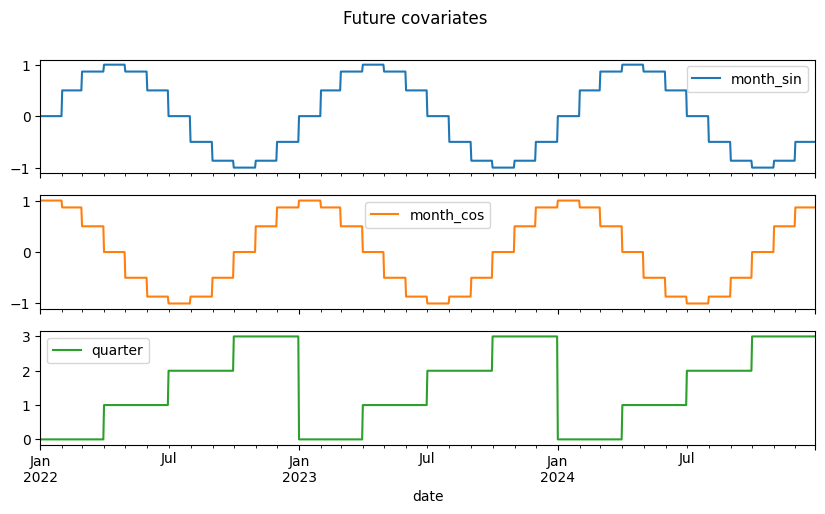

In [50]:
# Future covariates can be modeled
from darts.utils.timeseries_generation import datetime_attribute_timeseries

# Model the month as a cyclic sinus / cosinus feature for the training data and 729 days into the future
future_covs = datetime_attribute_timeseries(ts_target_train, attribute="month", cyclic=True, add_length=729)
# Encode the quarter for the training data and 729 days into the future
future_covs = future_covs.stack(
    datetime_attribute_timeseries(ts_target_train, attribute="quarter", add_length=729)
)
future_covs = future_covs.astype(np.float32)

# Plot the future covariates
future_covs.to_dataframe().loc['2022':].plot(figsize=(10, 5), title="Future covariates", subplots=True)
plt.show()

The `future_covs` series above is shown for **illustration**, it demonstrates how to manually encode calendar features (month as cyclic sine/cosine, quarter) as future-known covariates.

In this notebook the TFT model is configured with `add_encoders`, which **generates these features automatically** at training and prediction time. There is no need to pass `future_covs` explicitly to `fit()` or `predict()`. If you want full control over future covariates instead, remove `add_encoders` and pass your hand-crafted series via the `future_covariates` argument.

## Forecasting with Temporal Fusion Transformer

We apply a transformer-based deep learning model, the **Temporal Fusion Transformer (TFT)**. This model handles complex, multivariate time series using attention mechanisms, interpretable variable selection, and probabilistic forecasting.

**From darts' docs (https://unit8co.github.io/darts/userguide.html):**

Darts' TFTModel incorporates the following main components from the original TFT architecture:

* **Gating mechanisms**: skip over unused components of the model architecture
* **Variable selection networks**: select relevant input variables at each time step
* **Temporal processing** of past and future input with LSTMs (long short-term memory)
* **Multi-head attention**: captures long-term temporal dependencies
* **Prediction intervals**: produces quantile forecasts instead of deterministic point estimates by default

> **Pitfall:** The default TFT loss in darts is quantile loss (pinball loss), not MSE. This means the `mean` output is the median forecast, not the expected value. If you only need point predictions, set `likelihood=None` and `loss_fn=torch.nn.MSELoss()`, this typically also speeds up training.

### Data Scaling

Transformers, like most ML models, are sensitive to the scale of input features. Scaling the data ensures faster and more stable training, and helps the model treat all variables fairly.

In [10]:
from darts.dataprocessing.transformers import Scaler

In [ ]:
# Scale the time series (note: we avoid fitting the transformer on the validation set)
transformer_target = Scaler()
train_transformed = transformer_target.fit_transform(ts_target_train)
val_transformed = transformer_target.transform(ts_target_val)

In [12]:
# Scale the past covariates
transformer_past_covs = Scaler()
past_covs_train_transformed = transformer_past_covs.fit_transform(ts_covs_train)
past_covs_val_transformed = transformer_past_covs.transform(ts_covs_val)

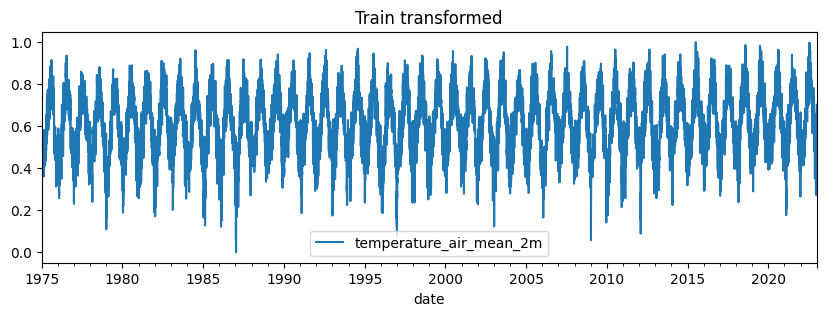

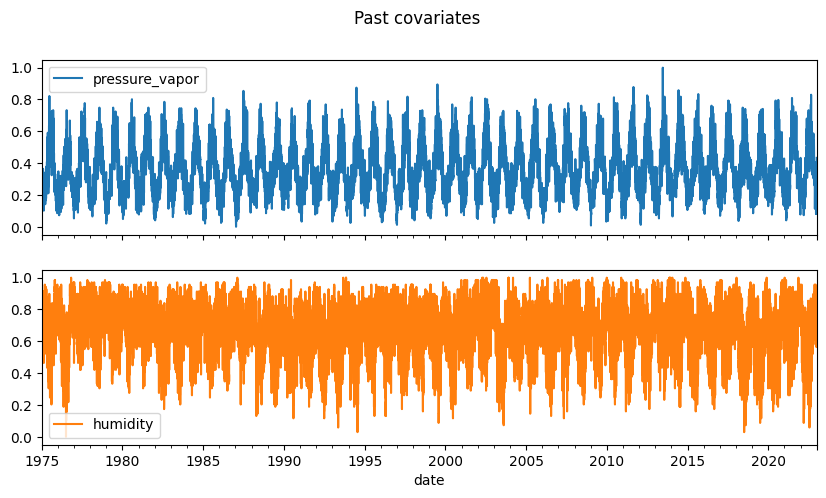

In [45]:
# Plot the transformed training data and covariates
train_transformed.to_dataframe().plot(title="Train transformed", figsize=(10, 3))
plt.show()
past_covs_train_transformed.to_dataframe().plot(subplots=True, title="Past covariates", figsize=(10, 5))
plt.show()

### Training and Hyperparameter Optimization

Tuning parameters like `input_chunk_length`, `hidden_size`, or `dropout` has a major impact on TFT performance. We use **Optuna** to search the hyperparameter space efficiently with a multi-objective approach.

**Strategy:**
- The `objective_tft` function trains a model on a smaller data subset and returns two metrics: **RMSE** and **MAPE**
- Optuna runs a **multi-objective** search (`directions=["minimize", "minimize"]`), finding the Pareto-optimal set of parameter combinations rather than a single winner
- We use data from 2015 onwards for HPO to keep each trial fast, then retrain the best configuration on the full training set

> **Pitfall:** With `n_trials=10` and `n_epochs` up to 50, HPO can take 30–60+ minutes. Reduce `n_trials`, tighten the epoch range, or cap `output_chunk_length` for faster exploration. Alternatively, run HPO once, record the best params, and hardcode them for future runs (see the example params below).

In [14]:
# Take a smaller sample of the data for the hyperparameter search
_, train_transformed_small = train_transformed.split_before(pd.Timestamp("2015"))
_, past_covs_train_transformed_small = past_covs_train_transformed.split_before(pd.Timestamp("2015"))
covs_slice_transformed_small = transformer_past_covs.transform(ts_covs.slice(pd.Timestamp("2015"), pd.Timestamp("2025")))

print("Smaller target data:", train_transformed_small.start_time(), train_transformed_small.end_time())
print("Smaller past covariates:", past_covs_train_transformed_small.start_time(), past_covs_train_transformed_small.end_time())
print("Smaller past covariates including validation time span:", covs_slice_transformed_small.start_time(), covs_slice_transformed_small.end_time())

Smaller target data: 2015-01-01 00:00:00 2022-12-31 00:00:00
Smaller past covariates: 2015-01-01 00:00:00 2022-12-31 00:00:00
Smaller past covariates including validation time span: 2015-01-01 00:00:00 2024-12-31 00:00:00


In [21]:
from darts.models import TFTModel

# Create a TFT model with given parameters
def create_tft_model(
    input_chunk_length=24, 
    output_chunk_length=24, 
    hidden_size=16, 
    lstm_layers=1, 
    num_attention_heads=4,
    full_attention=False, 
    feed_forward="GatedResidualNetwork", 
    dropout=0.1, 
    hidden_continuous_size=8,
    batch_size=32, 
    n_epochs=100, 
    lr=1e-3):

    model = TFTModel(
        model_name="TFT_Temp",
        input_chunk_length = input_chunk_length,
        output_chunk_length = output_chunk_length,
        hidden_size = hidden_size,
        lstm_layers = lstm_layers,
        num_attention_heads = num_attention_heads,
        full_attention = full_attention,
        feed_forward = feed_forward,
        dropout = dropout,
        hidden_continuous_size = hidden_continuous_size,
        batch_size = batch_size,
        n_epochs = n_epochs,
        use_static_covariates = False,
        # Dict to define the automatic generation and use of covariates
        add_encoders =  {
            # Cyclic sinus / cosinus encoded month
            'cyclic': {'past': ['month'], 'future': ['month']},
            # Encoding of the quarter
            'datetime_attribute': {'past': ['quarter'], 'future': ['quarter']},
            # Add positional values to future covariates, relative to prediction point
            'position': {'past': ['relative'], 'future': ['relative']},
            # Scale covariates
            'transformer': Scaler(),
        },
        random_state = 42,
        force_reset=True,
        optimizer_kwargs={"lr": lr},
        pl_trainer_kwargs={
            "accelerator": "auto", 
            "devices": "auto",
        }
    )

    return model

In [ ]:
from darts.metrics import rmse, mape
import optuna

def objective_tft(trial):
    # Hyperparameter search space
    # Number of time steps in the past to take as a model input
    input_chunk_length = trial.suggest_int("input_chunk_length", low=30, high=180, step=30)
    # Number of time steps predicted at once (per chunk) by the internal model
    output_chunk_length = trial.suggest_int("output_chunk_length", low=30, high=180, step=30)
    # Hidden state size of the TFT, common across the internal TFT architecture
    hidden_size = trial.suggest_categorical("hidden_size", [16, 32, 64])
    # Number of layers for the LSTM Encoder and Decoder
    lstm_layers = trial.suggest_int("lstm_layers", low=1, high=2, step=1)
    # Number of attention heads
    num_attention_heads = trial.suggest_int("num_attention_heads", low=2, high=6, step=2)
    # Whether to attend to previous, current, and future time steps or to previous only (False)
    full_attention = trial.suggest_categorical("full_attention", [True, False])
    # Type of GLU (Gated Linear Units) variant's FeedForward Network
    feed_forward = trial.suggest_categorical("feed_forward", ["GatedResidualNetwork", "SwiGLU"])
    # Fraction of neurons affected by dropout
    dropout = trial.suggest_float("dropout", 0.1, 0.5, step=0.1)
    # Default for hidden size for processing continuous variables
    hidden_continuous_size = trial.suggest_categorical("hidden_continuous_size", [8, 16, 32])
    # Number of time series input and output sequences used in each training pass
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    # Number of epochs over which to train the model
    n_epochs = trial.suggest_int("n_epochs", 10, 50, step=10)
    # Learning rate for the optimizer
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)

    # Create the TFT model
    tft_model = create_tft_model(
        input_chunk_length=input_chunk_length,
        output_chunk_length=output_chunk_length,
        hidden_size=hidden_size,
        lstm_layers=lstm_layers,
        num_attention_heads=num_attention_heads,
        full_attention=full_attention,
        feed_forward=feed_forward,
        dropout=dropout,
        hidden_continuous_size=hidden_continuous_size,
        batch_size=batch_size,
        n_epochs=n_epochs,
        lr=lr
    )

    # Fit the model with past covariates for the time span of the training data
    tft_model.fit(
        series=train_transformed_small,
        past_covariates=past_covs_train_transformed_small,
        verbose=False,
    )

    # Predict and validate, we need the past covariates also cover the prediction horizon n
    predictions_tft = tft_model.predict(
        n=729,
        past_covariates=covs_slice_transformed_small,
        show_warnings=False,
    )

    # Compute regression / forecast scores on original scale
    predictions_tft_inv = transformer_target.inverse_transform(predictions_tft)
    val_inv = transformer_target.inverse_transform(val_transformed)
    # Root Mean Squared Error
    score_rmse = rmse(val_inv, predictions_tft_inv)
    # Mean Absolute Percentage Error
    score_mape = mape(val_inv, predictions_tft_inv)

    return score_rmse, score_mape

In [ ]:
# Execute the training and optimization
# Note: The search space is large, the model complex, lots of trials especially with more epochs may take quite a while
n_trials = 10
study_tft = optuna.create_study(directions=["minimize", "minimize"])
study_tft.optimize(objective_tft, n_trials=n_trials, show_progress_bar=True)

In [26]:
# Lets have a look at the best parameter combination found by optuna
print("Number of best TFT trials found:", len(study_tft.best_trials))
for i, trial in enumerate(study_tft.best_trials):
    print(f"Trial {i+1}: RMSE={trial.values[0]:.4f}, MAPE={trial.values[1]:.4f}, Params={trial.params}")

Number of best TFT trials found: 1
Trial 1: RMSE=0.0887, MAPE=12.1754, Params={'input_chunk_length': 150, 'output_chunk_length': 60, 'hidden_size': 64, 'lstm_layers': 2, 'num_attention_heads': 2, 'full_attention': True, 'feed_forward': 'SwiGLU', 'dropout': 0.1, 'hidden_continuous_size': 16, 'batch_size': 64, 'n_epochs': 30, 'lr': 0.003452359418049642}


With `directions=["minimize", "minimize"]`, Optuna performs **multi-objective optimisation**. Rather than a single best trial, it returns a **Pareto front**. All trials where no other trial is strictly better on *both* RMSE and MAPE simultaneously.

If only one trial appears (as above), it dominated all others on both metrics. In practice you may find several Pareto-optimal trials with different trade-offs (e.g. lower RMSE but higher MAPE). In that case, pick based on which metric matters more for your use case.

In [51]:
# Optuna also provides nice visualizations of the optimization process
from plotly.io import show

opt_hist = optuna.visualization.plot_optimization_history(study_tft, target=lambda t: t.values[1], target_name="MAPE")
opt_hist.update_layout(title="Optuna optimization history", width=800, height=400)
show(opt_hist)
coord = optuna.visualization.plot_parallel_coordinate(study_tft, target=lambda t: t.values[1], target_name="MAPE")
coord.update_layout(title="Optuna optimization parallel coordinates", width=800, height=400)
show(coord)

Example of a well-performing parameter set found by Optuna. Use this as a starting point if you want to skip HPO and go directly to final training.

Key observations from this configuration:
- `input_chunk_length=150`: the model uses ~5 months of history per prediction step
- `output_chunk_length=60`: predicts 60 days in one forward pass; longer horizons auto-regress
- `hidden_size=64`, `lstm_layers=2`: moderately deep, sufficient for this dataset without overfitting
- `full_attention=True`: attends to both past and future encoder steps, not just past

```python
{
    'input_chunk_length': 150, 
    'output_chunk_length': 60, 
    'hidden_size': 64, 
    'lstm_layers': 2, 
    'num_attention_heads': 2, 
    'full_attention': True, 
    'feed_forward': 'SwiGLU', 
    'dropout': 0.1, 
    'hidden_continuous_size': 16, 
    'batch_size': 64, 
    'n_epochs': 30, 
    'lr': 0.003452359418049642
}
```

In [ ]:
# Get best TFT parameters
best_params = study_tft.best_trials[0].params

# Train the TFT model with the best parameter combination on the whole training data set
# This also takes quite a while
tft_model = create_tft_model(
    input_chunk_length = best_params['input_chunk_length'],
    output_chunk_length = best_params['output_chunk_length'],
    hidden_size = best_params['hidden_size'],
    lstm_layers = best_params['lstm_layers'],
    num_attention_heads = best_params['num_attention_heads'],
    full_attention = best_params['full_attention'],
    feed_forward = best_params['feed_forward'],
    dropout = best_params['dropout'],
    hidden_continuous_size = best_params['hidden_continuous_size'],
    batch_size = best_params['batch_size'],
    n_epochs = best_params['n_epochs'],
    lr = best_params['lr']
)

# Fit the model
tft_model.fit(series=train_transformed, past_covariates=past_covs_train_transformed, verbose=True)

In [29]:
# Save the trained model
tft_model.save("my_tft_model.pt")

### Load, Predict and Evaluate

We now load an already pretrained best-performing model and use it to make predictions. We then evaluate its performance using error metrics like RMSE or MAPE to understand how well it learned the time series.

In [30]:
pretrained_tft_model = TFTModel.load("my_tft_model.pt")
pretrained_tft_model.model_params

OrderedDict([('output_chunk_shift', 0),
             ('hidden_size', 64),
             ('lstm_layers', 2),
             ('num_attention_heads', 2),
             ('full_attention', True),
             ('feed_forward', 'SwiGLU'),
             ('dropout', 0.1),
             ('hidden_continuous_size', 16),
             ('categorical_embedding_sizes', None),
             ('add_relative_index', False),
             ('skip_interpolation', False),
             ('loss_fn', None),
             ('likelihood', None),
             ('norm_type', 'LayerNorm'),
             ('use_static_covariates', False),
             ('model_name', 'TFT_Temp'),
             ('input_chunk_length', 150),
             ('output_chunk_length', 60),
             ('batch_size', 64),
             ('n_epochs', 30),
             ('add_encoders',
              {'cyclic': {'past': ['month'], 'future': ['month']},
               'datetime_attribute': {'past': ['quarter'],
                'future': ['quarter']},
               '

In [ ]:
pred_tft = pretrained_tft_model.predict(
    n=180,
    past_covariates=transformer_past_covs.transform(ts_covs),
    show_warnings=False,
)

# Compute MAPE on original scale for interpretability
pred_tft_inv = transformer_target.inverse_transform(pred_tft)
val_inv = transformer_target.inverse_transform(val_transformed)
print("MAPE for model pretrained on full dataset:", mape(val_inv, pred_tft_inv))

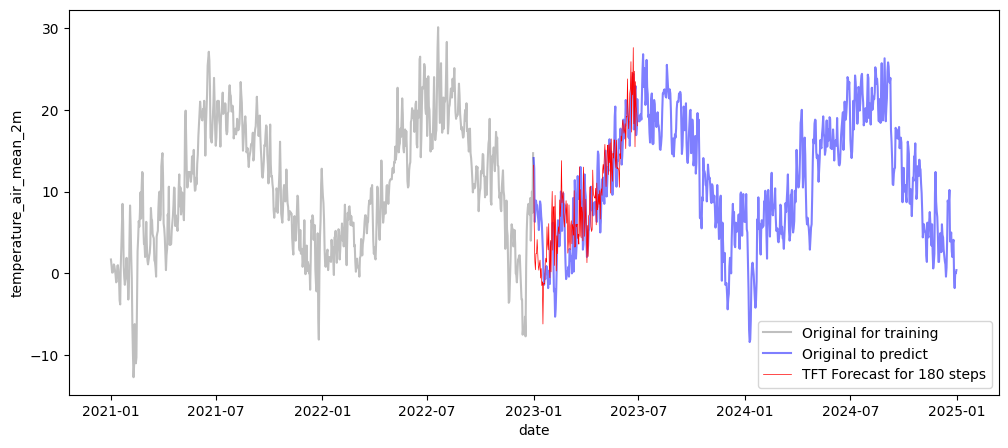

In [37]:
# Inverse transform the predictions back to original scale
pred_tft_series = transformer_target.inverse_transform(pred_tft).to_series()

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(x=df_temp_visu.loc["2021":"2022"].index, y=df_temp_visu.loc["2021":"2022"], 
             alpha=0.5, color='grey', label='Original for training', ax=ax)
sns.lineplot(x=df_temp_visu.loc["2023":].index, y=df_temp_visu.loc["2023":], 
             alpha=0.5, color='blue', label='Original to predict', ax=ax)
sns.lineplot(x=pred_tft_series.index, y=pred_tft_series, 
             color='red', linewidth=0.5, label=f'TFT Forecast for {len(pred_tft_series)} steps', ax=ax)
plt.show()

### Backtesting with Historical Forecasts

Backtesting simulates how the model would have performed making rolling predictions in the past. Instead of a single evaluation at the end of the training period, `historical_forecasts` steps through a range of starting points and produces a forecast at each step.

Key parameters:
- `start`: the earliest point from which forecasts are generated
- `forecast_horizon=1`: predict one step ahead at each position
- `stride=1`: advance one step at a time (densest possible rolling evaluation)
- `retrain=False`: reuse the already-trained model - fast, but the model does not adapt to newly seen data

> **Pitfall:** `retrain=False` uses a single fixed model across all windows, which is realistic for production (no daily retraining) but ignores concept drift. Setting `retrain=True` is more statistically honest but can take hours for long daily series.

In [38]:
# Run historical forecasts
historical_forecasts = pretrained_tft_model.historical_forecasts(
    series=train_transformed,
    past_covariates=past_covs_train_transformed,
    start=pd.Timestamp("2019"),
    forecast_horizon=1,
    stride=1,
    retrain=False,
    verbose=True
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/matthias/Documents/Git/Trainings/tsa-overview/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Predicting: |          | 0/? [00:00<?, ?it/s]

In [39]:
# Align true values and forecast for scoring
intersect = train_transformed.slice_intersect(historical_forecasts)
rmse_val = rmse(intersect, historical_forecasts)
mape_val = mape(intersect, historical_forecasts)
print(rmse_val, mape_val)

0.068573155 9.087163


Backtesting scores here are computed in the **scaled space** (values roughly in [0, 1]). To interpret RMSE in the original unit (°C), inverse-transform both series before scoring.

A MAPE of ~9% on 1-step-ahead daily temperature forecasts is competitive with well-tuned classical models on this dataset.

> **Pitfall:** Backtesting with `forecast_horizon=1` measures only 1-day-ahead accuracy. Real deployments often require multi-step forecasts (e.g. 7 or 30 days ahead), where errors accumulate through auto-regression. Always evaluate at your intended operational horizon.

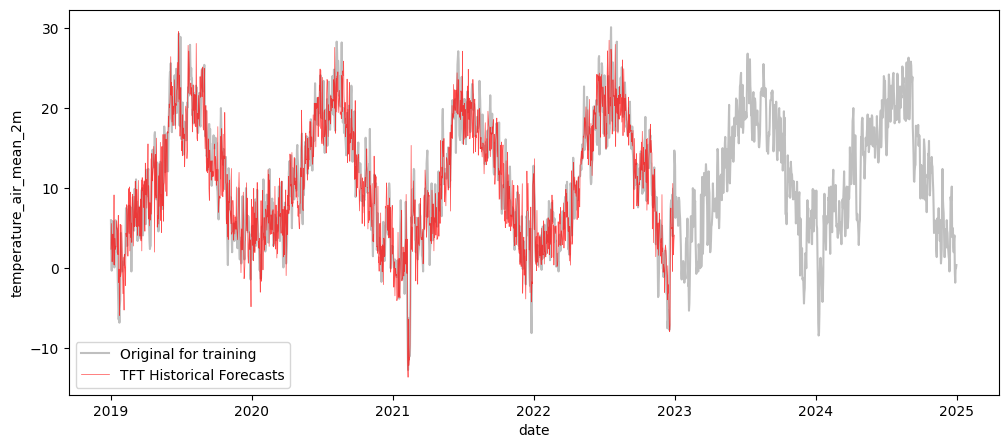

In [52]:
# Inverse transform the historical forecasts back to original scale
historical_forecasts_series = transformer_target.inverse_transform(historical_forecasts).to_series()

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(x=df_temp_visu.index, y=df_temp_visu, 
             alpha=0.5, color='grey', label='Original for training', ax=ax)
sns.lineplot(x=historical_forecasts_series.index, y=historical_forecasts_series, 
             alpha=0.7, color='red', linewidth=0.5, label=f'TFT Historical Forecasts', ax=ax)
plt.show()